# 09 — Validating a Device Simulator
## How do we know the simulation is right? Test structures, exact identities and textbook limits

A simulator always returns *a* number. Before trusting it for a device nobody has built, engineers check it against
situations where the right answer is known. This notebook runs the checks used to validate the other tutorials. Each
check isolates **one** model: the intrinsic density, mobility, velocity saturation, the diode equation, the mesh, and
the arithmetic itself. It then compares that model with the literature.

**Learning objectives**
1. Build minimal *test structures* (a resistor bar, a 1-D junction) that isolate one piece of physics.
2. Measure PADRE's intrinsic density, mobility vs. doping, and velocity-field curve, and compare with published models.
3. Run a controlled experiment that exposes a modelling artefact, and fix it.
4. Perform a mesh-convergence study.
5. Use exact identities (Kirchhoff's current law) to find the numerical noise floor.

**Principle:** change one thing at a time, and compare with something you can calculate independently.

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────
# PADRE is a compiled simulator. On nanoHUB it lives in an environment
# module that must be loaded into this Python kernel before the first
# simulation runs; elsewhere, PADRE just needs to be on your PATH.
import shutil
from nanohubpadre import use

if shutil.which("padre") is None:
    try:
        use("padre-2.4E-r15")          # nanoHUB module name
    except Exception as exc:           # not on nanoHUB: that is fine
        print("Could not load the PADRE module:", exc)

print("PADRE executable:", shutil.which("padre") or "NOT FOUND - simulations will fail")

PADRE executable: /apps/share64/debian10/padre/padre-2.4E/r15/bin/padre


In [2]:
# ── Physical constants: textbook values vs. the values PADRE really uses ──
# PADRE prints its constants with `MODELS ... PRINT`. A fair comparison of
# simulation against a formula must feed the formula PADRE's numbers:
# e.g. the textbook n_i = 1.5e10 cm^-3 alone changes every analytic diode
# current by (1.5e10 / 9.963e9)^2 = 2.3x before any physics is compared.
import numpy as np

Q      = 1.602e-19        # elementary charge (C)
KT     = 0.025851         # thermal voltage kT/q at 300 K (V)
EPS0   = 8.854e-14        # vacuum permittivity (F/cm)
EPS_SI = 11.8 * EPS0      # silicon permittivity in PADRE (F/cm)
EPS_OX = 3.9 * EPS0       # SiO2 permittivity (F/cm)
NI     = 9.963e9          # intrinsic carrier density of Si at 300 K (cm^-3)
EG     = 1.12             # band gap (eV)
CHI_SI = 4.17             # electron affinity of Si in PADRE (eV)
NC, NV = 3.2e19, 2.03e19  # effective densities of states (cm^-3)

# The values most textbooks quote (e.g. Sze & Ng, Pierret), for contrast.
TEXTBOOK = dict(NI=1.5e10, EPS_SI=11.7 * EPS0, CHI_SI=4.05, NC=2.8e19, NV=1.04e19)


def compare(rows, title="Textbook vs. PADRE"):
    """Print a comparison table.

    rows: list of (quantity, textbook_value, padre_value, unit, why_different)
    """
    print(title)
    print("-" * 125)
    print(f"{'quantity':<40}{'textbook':>12}{'PADRE':>12}{'diff':>9}   why they differ")
    print("-" * 125)
    for name, tb, pd, unit, why in rows:
        d = f"{(pd - tb) / tb * 100:>+8.1f}%" if tb else "     n/a "
        print(f"{name + ' (' + unit + ')':<40}{tb:>12.4g}{pd:>12.4g}{d}   {why}")
    print("-" * 125)


compare([
    ("intrinsic density n_i", TEXTBOOK["NI"], NI, "cm^-3",
     "modern value (Sproul & Green 1991); 1.5e10 is the older textbook number"),
    ("Si permittivity", TEXTBOOK["EPS_SI"], EPS_SI, "F/cm", "PADRE uses eps_r = 11.8, Sze uses 11.7"),
    ("electron affinity chi", TEXTBOOK["CHI_SI"], CHI_SI, "eV", "PADRE (like Silvaco Atlas) uses 4.17"),
    ("conduction-band DOS Nc", TEXTBOOK["NC"], NC, "cm^-3", "different effective-mass fit"),
    ("valence-band DOS Nv", TEXTBOOK["NV"], NV, "cm^-3", "different effective-mass fit"),
], title="Material constants")

Material constants
-----------------------------------------------------------------------------------------------------------------------------
quantity                                    textbook       PADRE     diff   why they differ
-----------------------------------------------------------------------------------------------------------------------------
intrinsic density n_i (cm^-3)                1.5e+10   9.963e+09   -33.6%   modern value (Sproul & Green 1991); 1.5e10 is the older textbook number
Si permittivity (F/cm)                     1.036e-12   1.045e-12    +0.9%   PADRE uses eps_r = 11.8, Sze uses 11.7
electron affinity chi (eV)                      4.05        4.17    +3.0%   PADRE (like Silvaco Atlas) uses 4.17
conduction-band DOS Nc (cm^-3)               2.8e+19     3.2e+19   +14.3%   different effective-mass fit
valence-band DOS Nv (cm^-3)                 1.04e+19    2.03e+19   +95.2%   different effective-mass fit
---------------------------------------------------

---
## 1. Intrinsic density and built-in potential

In a neutral region at equilibrium, the **mass-action law** $np=n_i^2$ holds exactly for Boltzmann statistics. A 1-D
p-n junction gives us a p-type and an n-type neutral region to test it in, and the potential step between them is
$V_{bi}$. We build the structure by hand, so we control every card.

In [3]:
from nanohubpadre import (Simulation, Mesh, Region, Electrode, Doping, Contact, Material,
                          Models, System, Solve, Log, Plot1D)

def junction(title="ni test"):
    s = Simulation(title=title)
    s.mesh = Mesh(nx=101, ny=3)
    s.mesh.add_x_mesh(1, 0.0); s.mesh.add_x_mesh(101, 2.0)
    s.mesh.add_y_mesh(1, 0.0); s.mesh.add_y_mesh(3, 1.0)
    s.add_region(Region(1, ix_low=1, ix_high=101, iy_low=1, iy_high=3, silicon=True))
    s.add_electrode(Electrode(1, ix_low=1, ix_high=1, iy_low=1, iy_high=3))
    s.add_electrode(Electrode(2, ix_low=101, ix_high=101, iy_low=1, iy_high=3))
    s.add_doping(Doping(uniform=True, p_type=True, concentration=1e17, x_left=0, x_right=0.99, y_top=0, y_bottom=1))
    s.add_doping(Doping(uniform=True, n_type=True, concentration=1e17, x_left=1.01, x_right=2, y_top=0, y_bottom=1))
    s.add_contact(Contact(all_contacts=True, neutral=True))
    s.models = Models(temperature=300, srh=True, conmob=True, print_models=True)   # PRINT lists PADRE's constants
    s.system = System(electrons=True, holes=True, newton=True)
    s.add_solve(Solve(initial=True))
    for q_, f in (("electrons", "n"), ("holes", "p"), ("potential", "psi")):
        s.add_command(Plot1D(**{q_: True}, x_start=0, y_start=0.5, x_end=2, y_end=0.5, outfile=f, ascii=True))
    return s

sj = junction()
res = sj.run()
n, p, psi = (sj.outputs.get(k) for k in ("n", "p", "psi"))
ni_p = np.sqrt(n.y[3] * p.y[3])            # deep in the p region
ni_n = np.sqrt(n.y[-3] * p.y[-3])          # deep in the n region
vbi = psi.y[-3] - psi.y[3]
compare([
    ("n_i from n*p, p side", NI, ni_p, "cm^-3", "mass-action law, Boltzmann statistics"),
    ("n_i from n*p, n side", NI, ni_n, "cm^-3", "same"),
    ("n_i vs textbook 1.5e10", TEXTBOOK["NI"], ni_n, "cm^-3", "PADRE uses the modern value"),
    ("V_bi", KT * np.log(1e34 / NI ** 2), vbi, "V", "kT/q ln(NaNd/n_i^2) with PADRE's n_i"),
], title="Intrinsic density and built-in potential")

Intrinsic density and built-in potential
-----------------------------------------------------------------------------------------------------------------------------
quantity                                    textbook       PADRE     diff   why they differ
-----------------------------------------------------------------------------------------------------------------------------
n_i from n*p, p side (cm^-3)               9.963e+09   9.963e+09    -0.0%   mass-action law, Boltzmann statistics
n_i from n*p, n side (cm^-3)               9.963e+09   9.963e+09    -0.0%   same
n_i vs textbook 1.5e10 (cm^-3)               1.5e+10   9.963e+09   -33.6%   PADRE uses the modern value
V_bi (V)                                      0.8335      0.8335    +0.0%   kT/q ln(NaNd/n_i^2) with PADRE's n_i
-----------------------------------------------------------------------------------------------------------------------------


With `print_models=True`, PADRE prints its material table in the run log. That is where the constants used
throughout this series come from:

In [4]:
log = res.stdout
start = log.find("Material data")
print(log[start:start + 900])

Material data
num  r-perm    Egap     Affinity   Ec offset    Bulk qf   k-therm    Gen con
 1   11.80  1.1200E+00 4.1700E+00  0.0000E+00 0.0000E+00 1.4500E+00 4.0000E+13



                         Semiconductor data
num  stats     ni         An**      Ap**        Nc         Nv
 1   Boltz  9.963E+09  1.100E+02  3.000E+01  3.200E+19  2.030E+19

num    gcb        edb        gcv        eab        w2d      H-alphn    H-alphp
 1  2.000E+00  5.000E-02  4.000E+00  4.500E-02  1.000E-03  3.000E-05  2.000E-07


   Model flags :

     Incomp. ionization  = F
     Band-gap narrowing  = F

     SRH recombination   = T
     Conc-dep lifetime   = F
     Auger recombination = F
     Deep level traps    = F
     Radiative recomb    = F
     Impact ionization   = F
     Band-to-band tunnel = F
     Trap-assist tunnel  = F
     Stimulated emission = F

     Carrier-carr. scat. = F
     Neutral imp. scat.  


---
## 2. Mobility vs. doping: the resistor bar

A uniformly doped bar with ohmic contacts at both ends, biased at 10 mV, is a pure resistor: $I=qN\mu A\,V/L$.
Reading the current gives the mobility PADRE uses at that doping. We compare it with the **Masetti, Severi and Solmi
(1983)** fit to measured arsenic- and boron-doped silicon:
$$\mu(N)=\mu_0e^{-P_c/N}+\frac{\mu_{max}-\mu_0}{1+(N/C_r)^\alpha}-\frac{\mu_1}{1+(C_s/N)^\beta}.$$

In [5]:
def bar(typ, N, V=0.01, L=1.0, fldmob=False, e_drive=None, steps=None):
    s = Simulation(title=f"{typ}-bar {N:.0e}")
    s.mesh = Mesh(nx=21, ny=3)
    s.mesh.add_x_mesh(1, 0.0); s.mesh.add_x_mesh(21, L)
    s.mesh.add_y_mesh(1, 0.0); s.mesh.add_y_mesh(3, 1.0)
    s.add_region(Region(1, ix_low=1, ix_high=21, iy_low=1, iy_high=3, silicon=True))
    s.add_electrode(Electrode(1, ix_low=1, ix_high=1, iy_low=1, iy_high=3))
    s.add_electrode(Electrode(2, ix_low=21, ix_high=21, iy_low=1, iy_high=3))
    s.add_doping(Doping(uniform=True, concentration=N, n_type=(typ == "n"), p_type=(typ == "p"),
                        x_left=0, x_right=L, y_top=0, y_bottom=1))
    s.add_contact(Contact(all_contacts=True, neutral=True))
    s.models = Models(temperature=300, conmob=True, fldmob=fldmob, e_drive=e_drive)
    s.system = System(electrons=True, holes=True, newton=True)
    s.add_solve(Solve(initial=True))
    s.add_log(Log(ivfile="iv"))
    sign = -1 if typ == "p" else 1
    for v in (steps or [V]):
        s.add_solve(Solve(previous=True, v1=sign * v))
    return s

def masetti(N, typ):
    if typ == "n":
        mu0, mumax, mu1, Cr, Cs, a, b, Pc = 52.2, 1417, 43.4, 9.68e16, 3.43e20, 0.680, 2.0, 0.0
    else:
        mu0, mumax, mu1, Cr, Cs, a, b, Pc = 44.9, 470.5, 29.0, 2.23e17, 6.10e20, 0.719, 2.0, 9.23e16
    return mu0 * np.exp(-Pc / N) + (mumax - mu0) / (1 + (N / Cr) ** a) - mu1 / (1 + (Cs / N) ** b)

dopings = [1e14, 1e15, 1e16, 1e17, 1e18, 1e19]
mob = {"n": [], "p": []}
for typ in ("n", "p"):
    for N in dopings:
        s = bar(typ, N); s.run()
        I = abs(s.get_iv_data().get_currents(1)[-1])
        mob[typ].append(I * 1e-4 / (Q * N * 1e-8 * 0.01))     # mu = I L / (q N A V)

rows = [(f"mu_{typ}, N = {N:.0e}", masetti(N, typ), m, "cm2/Vs", "PADRE conmob vs Masetti 1983")
        for typ in ("n", "p") for N, m in zip(dopings, mob[typ])]
compare(rows, title="Low-field mobility")

Low-field mobility
-----------------------------------------------------------------------------------------------------------------------------
quantity                                    textbook       PADRE     diff   why they differ
-----------------------------------------------------------------------------------------------------------------------------
mu_n, N = 1e+14 (cm2/Vs)                        1404        1382    -1.6%   PADRE conmob vs Masetti 1983
mu_n, N = 1e+15 (cm2/Vs)                        1359        1348    -0.8%   PADRE conmob vs Masetti 1983
mu_n, N = 1e+16 (cm2/Vs)                        1177        1190    +1.2%   PADRE conmob vs Masetti 1983
mu_n, N = 1e+17 (cm2/Vs)                       727.1       739.6    +1.7%   PADRE conmob vs Masetti 1983
mu_n, N = 1e+18 (cm2/Vs)                       283.8       272.7    -3.9%   PADRE conmob vs Masetti 1983
mu_n, N = 1e+19 (cm2/Vs)                         108       101.6    -6.0%   PADRE conmob vs Masetti 1983
mu_p, N

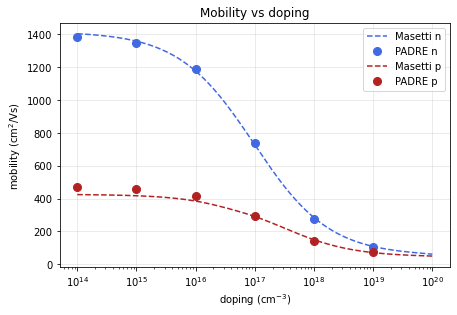

In [6]:
import matplotlib.pyplot as plt
Nf = np.logspace(14, 20, 200)
plt.figure(figsize=(7, 4.5))
for typ, col in (("n", "royalblue"), ("p", "firebrick")):
    plt.semilogx(Nf, masetti(Nf, typ), "--", color=col, label=f"Masetti {typ}")
    plt.semilogx(dopings, mob[typ], "o", color=col, ms=8, label=f"PADRE {typ}")
plt.xlabel("doping (cm$^{-3}$)"); plt.ylabel("mobility (cm$^2$/Vs)"); plt.title("Mobility vs doping")
plt.legend(); plt.grid(alpha=0.3); plt.show()

**What is different, and why:** PADRE's `conmob` agrees with Masetti within about ±6 % for electrons and ±10 % for holes.
It is a different fit to similar data (an analytic Caughey–Thomas-type form), and both lie within the scatter of the
measurements they were fitted to. Neither distinguishes **minority** from majority carriers, nor includes carrier-carrier
scattering (PADRE's `ccmob` adds the latter).

---
## 3. Velocity saturation

At high field, carriers lose energy to optical phonons as fast as they gain it, and their velocity saturates. The
Caughey–Thomas (1967) form
$$v=\frac{\mu_0E}{\big[1+(\mu_0E/v_{sat})^\beta\big]^{1/\beta}}$$
with $\beta$ = 2 (electrons) and 1 (holes), and $v_{sat}\approx1.07\times10^7$ and $0.84\times10^7$ cm/s, fits the
time-of-flight measurements of Canali et al. (1975). We push a 2 µm bar doped 10¹⁷ to 400 kV/cm.

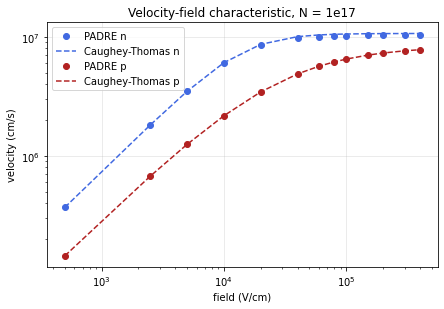

Saturation velocity
-----------------------------------------------------------------------------------------------------------------------------
quantity                                    textbook       PADRE     diff   why they differ
-----------------------------------------------------------------------------------------------------------------------------
v at 400 kV/cm (n) (cm/s)                  1.069e+07   1.034e+07    -3.3%   v_sat: Canali 1.07e7 vs PADRE 1.035e7
v at 400 kV/cm (p) (cm/s)                  7.815e+06   7.815e+06    +0.0%   same model and v_sat
-----------------------------------------------------------------------------------------------------------------------------


In [7]:
volts = [0.1, 0.5, 1, 2, 4, 8, 12, 16, 20, 30, 40, 60, 80]
vel = {}
for typ in ("n", "p"):
    s = bar(typ, 1e17, L=2.0, fldmob=True, steps=volts)
    s.run()
    d = s.get_iv_data()
    VV, II = np.abs(d.get_voltages(1)), np.abs(d.get_currents(1))
    m = VV > 0
    vel[typ] = (VV[m] / 2e-4, II[m] / (Q * 1e17 * 1e-8))       # field (V/cm), velocity (cm/s)

def caughey(E, typ):
    mu0 = mob[typ][dopings.index(1e17)]
    vs, b = (1.07e7, 2) if typ == "n" else (0.837e7, 1)
    return mu0 * E / (1 + (mu0 * E / vs) ** b) ** (1 / b)

plt.figure(figsize=(7, 4.5))
rows = []
for typ, col in (("n", "royalblue"), ("p", "firebrick")):
    E, v = vel[typ]
    plt.loglog(E, v, "o", color=col, label=f"PADRE {typ}")
    plt.loglog(E, caughey(E, typ), "--", color=col, label=f"Caughey-Thomas {typ}")
    rows.append((f"v at {E[-1] / 1e3:.0f} kV/cm ({typ})", float(caughey(E[-1], typ)), v[-1], "cm/s",
                 "v_sat: Canali 1.07e7 vs PADRE 1.035e7" if typ == "n" else "same model and v_sat"))
plt.xlabel("field (V/cm)"); plt.ylabel("velocity (cm/s)"); plt.title("Velocity-field characteristic, N = 1e17")
plt.legend(); plt.grid(alpha=0.3); plt.show()
compare(rows, title="Saturation velocity")

**What is different, and why:** holes follow Caughey–Thomas exactly. Electrons saturate at 1.035×10⁷ cm/s, 3 % below
Canali's 1.07×10⁷. PADRE uses a temperature-dependent $v_{sat}(T)=2.4\times10^7/(1+0.8e^{T/600})$ cm/s, which gives
1.035×10⁷ at 300 K; published values span 1.0–1.1×10⁷. Drift-diffusion cannot represent **velocity overshoot**, where
carriers briefly exceed $v_{sat}$ in sub-100 nm channels. Energy-balance or Monte-Carlo simulation is needed for that.

---
## 4. A controlled experiment: finding a modelling artefact

In a textbook-ideal diode, the Shockley equation should hold in the mid-bias range (notebook 02). With PADRE's
**default** settings for field-dependent mobility, it did not: the current was 11–40 % low and the ideality factor was 1.03.
Here is how to find the cause, changing one thing at a time.

`fldmob` needs a *driving force* for the field in $\mu(E)$. The option `e.drive` selects it: `qfb`, PADRE's effective
default, uses the gradient of the carrier's quasi-Fermi level. `eoqf` uses the electric field projected on the current
direction. For majority-carrier drift they are the same thing. For minority carriers *diffusing* toward an ohmic contact,
the quasi-Fermi gradient becomes huge as the density drops to its equilibrium value, so `qfb` wrongly treats diffusion
as high-field transport and throttles it at $v_{sat}$.

In [8]:
from nanohubpadre import create_pn_diode

def shockley_short(V, Na=1e17, Nd=1e17, length=1.0, area=1e-8):
    mun, mup = mob["n"][dopings.index(1e17)], mob["p"][dopings.index(1e17)]
    vbi_ = KT * np.log(Na * Nd / NI ** 2)
    W = np.sqrt(2 * EPS_SI / Q * (1 / Na + 1 / Nd) * (vbi_ - V))
    wqn = (length / 2) * 1e-4 - W / 2
    return Q * area * NI ** 2 * (mun + mup) * KT / (1e17 * wqn) * np.exp(V / KT)

variants = {"fldmob off": dict(fldmob=False), "qfb (PADRE default)": dict(drive="qfb"),
            "eoqf (library default)": dict(drive="eoqf")}
rows = []
for label, opt in variants.items():
    s = create_pn_diode(log_iv=True, forward_sweep=(0.0, 0.7, 0.05), fldmob=opt.get("fldmob", True))
    if "drive" in opt:
        s.models.e_drive = opt["drive"]
    s.run()
    d = s.get_iv_data()
    VV, II = d.get_voltages(1), np.abs(d.get_currents(1))
    for Vk in (0.3, 0.7):
        k = np.argmin(abs(VV - Vk))
        rows.append((f"{label}, {Vk} V", float(shockley_short(VV[k])), II[k], "A/um",
                     "field-dependent mobility " + ("off" if label.startswith("fldmob") else "on, e.drive=" + label.split()[0])))
compare(rows, title="PN diode current vs Shockley: one change at a time")

PN diode current vs Shockley: one change at a time
-----------------------------------------------------------------------------------------------------------------------------
quantity                                    textbook       PADRE     diff   why they differ
-----------------------------------------------------------------------------------------------------------------------------
fldmob off, 0.3 V (A/um)                   1.057e-13   1.077e-13    +1.9%   field-dependent mobility off
fldmob off, 0.7 V (A/um)                   5.198e-07   5.068e-07    -2.5%   field-dependent mobility off
qfb (PADRE default), 0.3 V (A/um)          1.057e-13   9.432e-14   -10.7%   field-dependent mobility on, e.drive=qfb
qfb (PADRE default), 0.7 V (A/um)          5.198e-07   3.097e-07   -40.4%   field-dependent mobility on, e.drive=qfb
eoqf (library default), 0.3 V (A/um)       1.057e-13   1.077e-13    +1.9%   field-dependent mobility on, e.drive=eoqf
eoqf (library default), 0.7 V (A/um)       

**Reading the experiment:** turning `fldmob` off restores Shockley agreement, so the artefact lives in the field-dependent
mobility. Keeping `fldmob` but switching the driving force to `eoqf` also restores it. Section 3 showed that `eoqf` leaves
genuine velocity saturation in a resistor unchanged. So the fix removes the artefact without removing the physics.
The library's PN-diode factory now uses `eoqf`. In a BJT the effect is only ~2 %, because base electrons are collected by a
reverse-biased junction, not an ohmic contact, and their quasi-Fermi gradient stays moderate.

---
## 5. Mesh convergence

A discretised answer must stop changing as the mesh is refined. We run the default diode with 100 to 800 nodes along the device.

In [9]:
rows = []
ref = None
for nx in (800, 400, 200, 100):
    s = create_pn_diode(nx=nx, log_iv=True, forward_sweep=(0.0, 0.6, 0.05))
    s.run()
    d = s.get_iv_data()
    VV, II = d.get_voltages(1), np.abs(d.get_currents(1))
    i06 = II[np.argmin(abs(VV - 0.6))]
    ref = ref or i06
    rows.append((f"I(0.6 V), nx = {nx}", ref, i06, "A/um", "reference: nx = 800"))
compare(rows, title="Mesh convergence of the diode current")

Mesh convergence of the diode current
-----------------------------------------------------------------------------------------------------------------------------
quantity                                    textbook       PADRE     diff   why they differ
-----------------------------------------------------------------------------------------------------------------------------
I(0.6 V), nx = 800 (A/um)                  1.097e-08   1.097e-08    +0.0%   reference: nx = 800
I(0.6 V), nx = 400 (A/um)                  1.097e-08   1.097e-08    +0.0%   reference: nx = 800
I(0.6 V), nx = 200 (A/um)                  1.097e-08   1.097e-08    +0.0%   reference: nx = 800
I(0.6 V), nx = 100 (A/um)                  1.097e-08   1.098e-08    +0.0%   reference: nx = 800
-----------------------------------------------------------------------------------------------------------------------------


The current changes by less than 0.1 % over an 8× change in node count, far less than any physical effect studied in these notebooks.
Convergence studies should be repeated whenever the geometry or the physics changes. A mesh that is fine for a diode's
forward current may be too coarse for its breakdown.

---
## 6. Exact identities: Kirchhoff's law and the noise floor

Current continuity is exact physics: in a two-terminal device $I_1+I_2=0$. Terminal currents are computed as differences
between large drift and diffusion fluxes, so they carry round-off that becomes visible when the current is tiny.

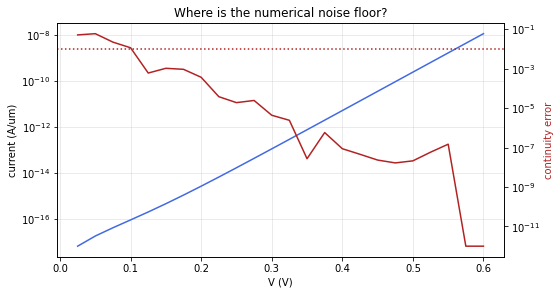

points with > 1 % imbalance: 4, all below I = 8.8e-17 A/um


In [10]:
s = create_pn_diode(log_iv=True, forward_sweep=(0.0, 0.6, 0.025))
s.run()
d = s.get_iv_data()
VV, II, err = d.get_voltages(1), np.abs(d.get_currents(1)), d.continuity_error()
fig, ax = plt.subplots(figsize=(8, 4.3))
m = VV > 0
ax.semilogy(VV[m], II[m], color="royalblue", label="|I|")
ax.set(xlabel="V (V)", ylabel="current (A/um)", title="Where is the numerical noise floor?")
ax2 = ax.twinx()
ax2.semilogy(VV[m], np.maximum(err[m], 1e-12), color="firebrick", label="|I1+I2| / |I|")
ax2.axhline(0.01, ls=":", color="firebrick"); ax2.set_ylabel("continuity error", color="firebrick")
ax.grid(alpha=0.3); plt.show()
floor = II[(err > 0.01) & (VV > 0)]
print(f"points with > 1 % imbalance: {len(floor)}, all below I = {floor.max() if len(floor) else 0:.1e} A/um")

Below roughly 10⁻¹⁶ A the balance fails: those "currents" are arithmetic noise, however smooth they look. Any quantity
extracted from them (reverse leakage, low-bias ideality) is meaningless. Scaling the device depth does **not** help, because
signal and noise scale together. Only stronger physics helps: shorter lifetimes, higher temperature, or larger doping gradients.

---
## 7. Validation checklist

| Check | Test structure | Reference | Result for PADRE 2.4E |
|---|---|---|---|
| $n_i$ | junction, neutral regions | $np=n_i^2$ | 9.96×10⁹ cm⁻³ |
| $V_{bi}$ | junction | $kT/q\ln(N_AN_D/n_i^2)$ | < 1 mV |
| mobility | resistor bars | Masetti 1983 | ±6 % (n), ±10 % (p) |
| saturation velocity | long bar, high field | Canali 1975 | 1.035×10⁷ cm/s (n), CT exact (p) |
| diode equation | 1-D diode | Shockley short base | few %, with `e.drive=eoqf` |
| mesh | diode, nx = 100–800 | self-convergence | < 0.1 % |
| arithmetic | any two-terminal | $I_1+I_2=0$ | floor ≈ 10⁻¹⁶ A |

## 8. Exercises
1. **Temperature.** Repeat §1 at 350 K. $n_i\propto T^{3/2}e^{-E_g/2kT}$: does PADRE's $n_i(350)$ match, if you allow $E_g$ to
   shrink with $T$ (Varshni)?
2. **Carrier-carrier scattering.** Add `ccmob=True` to the bar and forward-bias a diode to high injection. Where would
   you expect a difference?
3. **Your own check.** Pick a device from notebooks 02–08 and design a test that would catch a bug in it. The MOSFET
   $I_D\propto1/L$ test in notebook 04 caught a real one.

**Next →** [10 — The pntoy Diode: Band Diagrams Under Bias](10_pntoy_Band_Diagrams.ipynb) · **Back to →** [00 — Introduction](00_Introduction.ipynb)